In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Dataset Overview

This dataset contains historical flight information including airline, source city, destination city, journey date, departure time, arrival time, total stops, and ticket prices.

### Business Objective

The objective is to predict airline ticket prices based on flight details and travel characteristics.

### Why It Matters

Accurate fare prediction helps:

- Travelers find the best booking time.
- Airlines optimize pricing strategies.
- Travel agencies improve customer recommendations.

In [2]:
df=pd.read_excel("Flight_Fare.xlsx")

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [5]:
df.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
df.shape

(10683, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


### Observation

- The dataset contains both categorical and numerical variables.
- Flight fare is the target variable.
- Several date and time columns require feature extraction.

### Insight

Understanding data structure helps identify preprocessing requirements before model building.

In [8]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


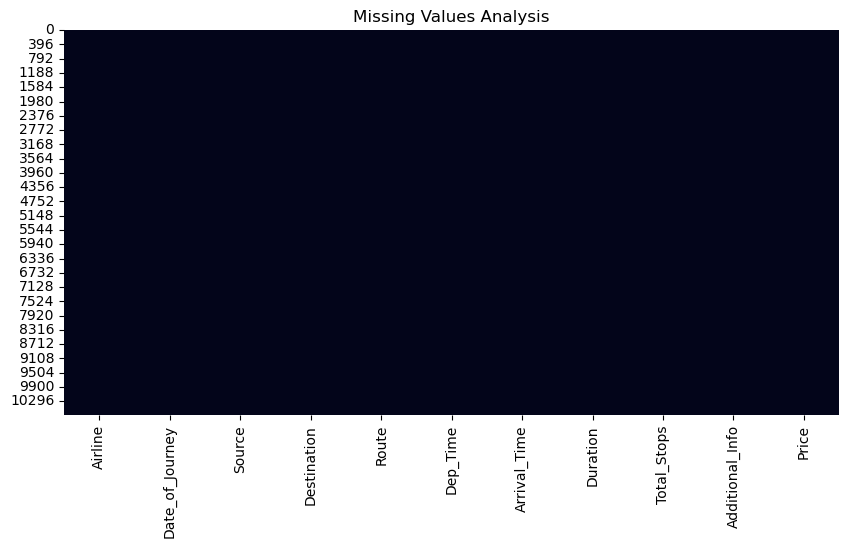

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Analysis")
plt.show()

## Missing Values Analysis
### Observation

The heatmap highlights missing values present in the dataset.

### Business Insight

Missing information can lead to inaccurate fare predictions and must be handled carefully.

## Flight Fare Distribution

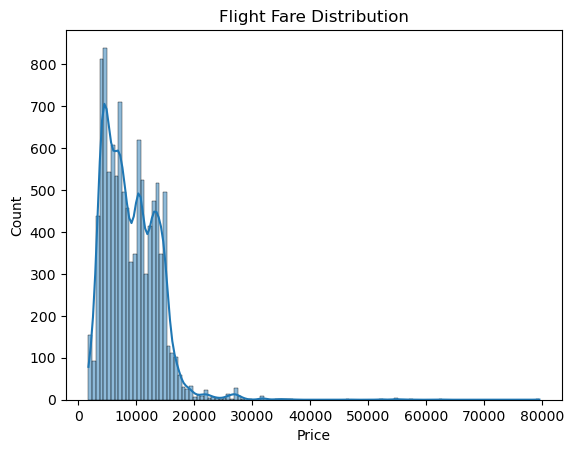

In [10]:
sns.histplot(df['Price'], kde=True)
plt.title("Flight Fare Distribution")
plt.show()

### Observation

Flight fares are not uniformly distributed and contain several high-price bookings.

### Insight

Premium-class flights and last-minute bookings often create higher fare values.

### Business Impact

Understanding fare distribution helps airlines analyze customer spending patterns.

## Airline wise price analysis

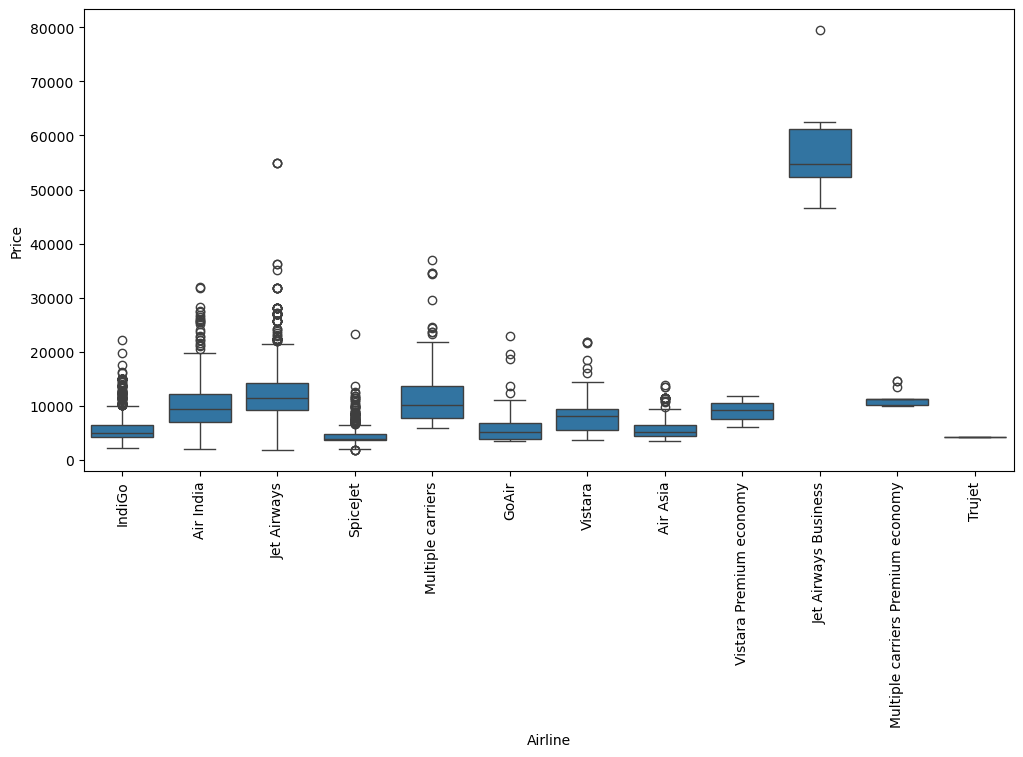

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.show()

### Observation

Different airlines exhibit significantly different pricing structures.

### Key Findings

- Premium airlines generally charge higher fares.
- Budget carriers maintain lower average ticket prices.

### Business Insight

Airline brand plays a major role in ticket pricing decisions.

## Source City analysis

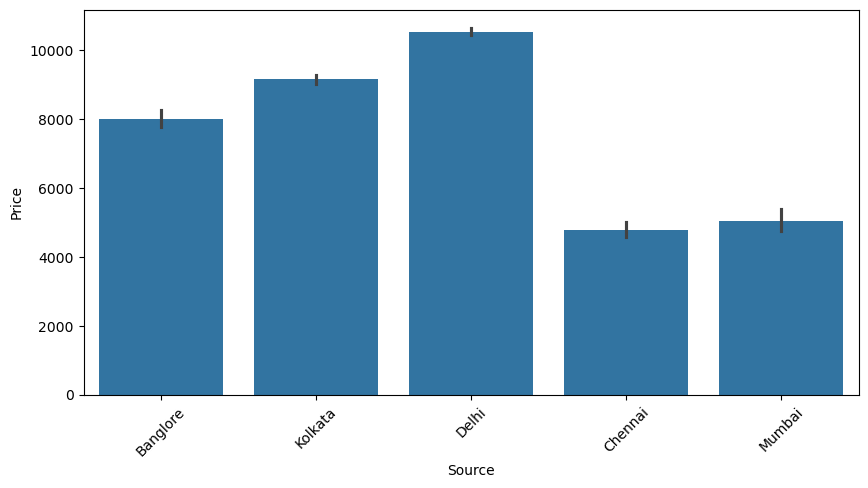

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x='Source', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

### Observation

Average ticket prices vary across departure cities.

### Insight

Major metropolitan airports tend to have higher average fares due to demand fluctuations.

### Business Impact

Location-based pricing can influence airline revenue optimization.

## Destination analysis

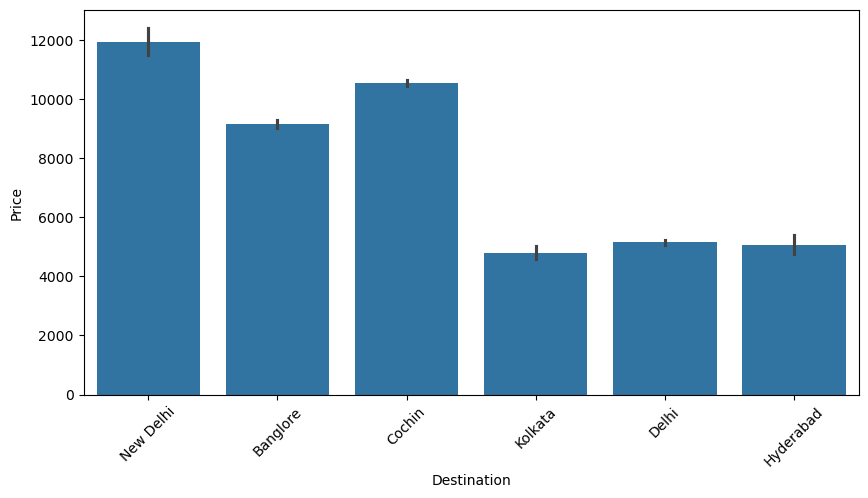

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(x='Destination', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

### Observation

Ticket prices vary significantly depending on destination.

### Insight

Popular destinations generally show higher average fares due to increased demand.

In [14]:
df.dropna(inplace=True)

In [15]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month
df["Journey_Year"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.year
df.drop("Date_of_Journey", axis=1, inplace=True)

In [16]:
def convert_duration(x):
    x = x.replace("h", " ").replace("m", " ").split()
    if len(x) == 2:
        return int(x[0])*60 + int(x[1])
    else:
        return int(x[0])*60
    
df["Duration_Time"] = df["Duration"].apply(convert_duration)
df.drop("Duration",axis=1,inplace=True)

In [17]:
from sklearn.preprocessing import LabelEncoder

le_airline = LabelEncoder()
le_source = LabelEncoder()
le_destination = LabelEncoder()

df["Airline"] = le_airline.fit_transform(df["Airline"])
df["Source"] = le_source.fit_transform(df["Source"])
df["Destination"] = le_destination.fit_transform(df["Destination"])

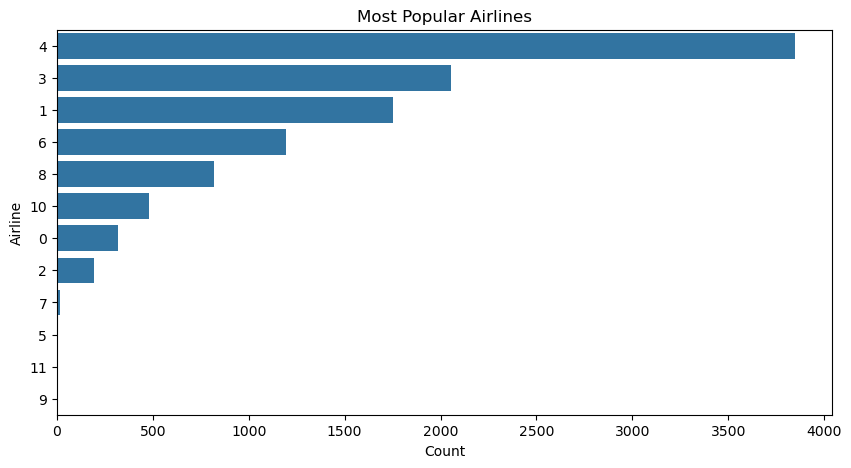

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Airline'], order=df['Airline'].value_counts().index)
plt.title('Most Popular Airlines')
plt.xlabel('Count')
plt.ylabel('Airline')
plt.show()

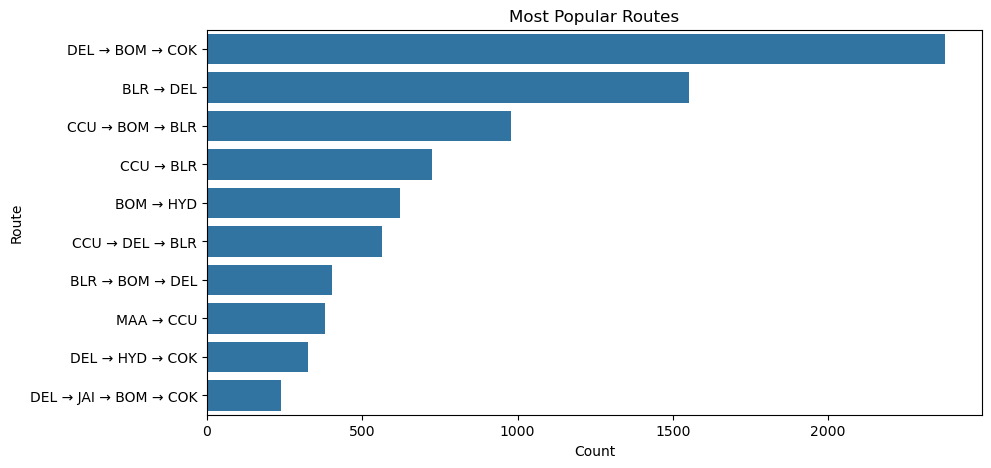

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Route'], order=df['Route'].value_counts().index[:10]) # Top 10 routes
plt.title('Most Popular Routes')
plt.xlabel('Count')
plt.ylabel('Route')
plt.show()

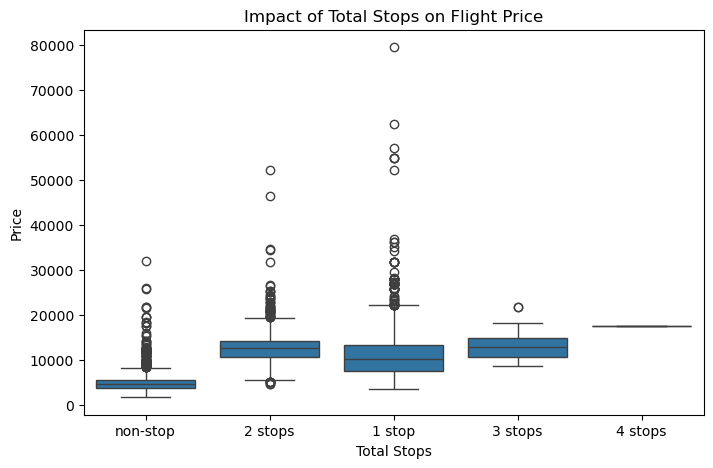

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Stops'], y=df['Price'])
plt.title('Impact of Total Stops on Flight Price')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.show()

### Observation

Flights with more stops generally have lower fares.

### Key Findings

- Non-stop flights command premium prices.
- Multi-stop flights are usually more economical.

### Business Insight

Passengers often trade convenience for lower ticket costs.

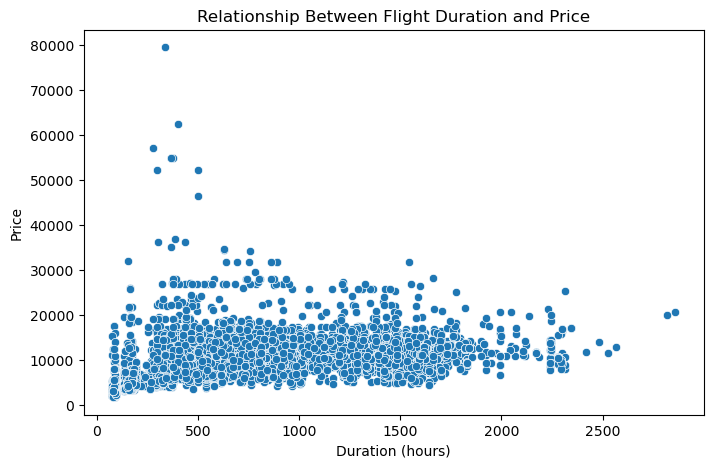

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Duration_Time'], y=df['Price'])
plt.title('Relationship Between Flight Duration and Price')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.show()

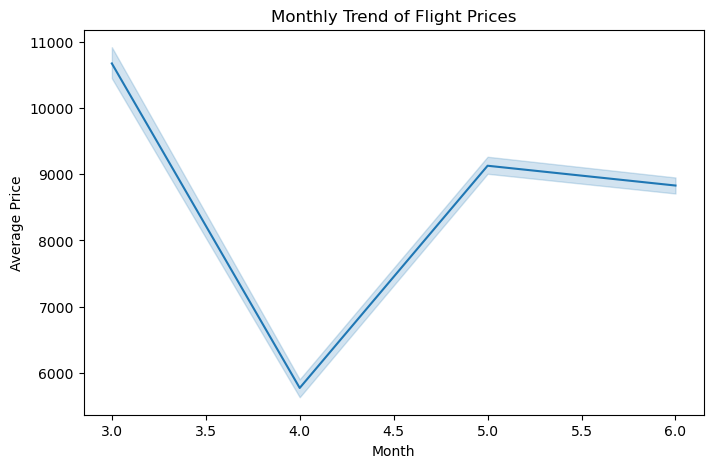

In [22]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Journey_Month'], y=df['Price'], estimator='mean')
plt.title('Monthly Trend of Flight Prices')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.show()

### Observation

Ticket prices fluctuate across months.

### Insight

Holiday seasons and peak travel periods drive fare increases.

### Business Impact

Seasonal pricing strategies significantly affect airline profitability.

<Axes: >

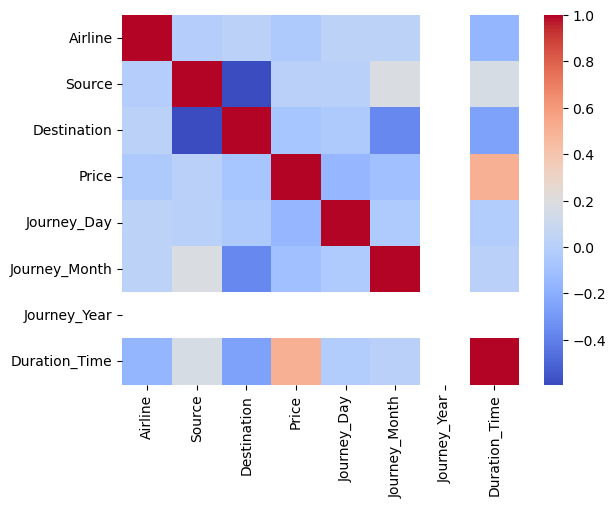

In [23]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

### Observation

The heatmap identifies relationships among numerical variables.

### Key Findings

- Duration strongly impacts fare.
- Number of stops influences pricing.
- Journey timing contributes to fare variation.

### Insight

Highly correlated variables provide strong predictive power.

## Feature Engineering

## Feature Engineering

Several new features were extracted from date and time columns:

- Journey Day
- Journey Month
- Departure Hour
- Departure Minute
- Arrival Hour
- Arrival Minute
- Flight Duration

### Why?

Machine learning algorithms cannot directly interpret raw datetime values.

In [24]:
df["Total_Stops"] = df["Total_Stops"].replace({"non-stop": 0,"1 stop": 1,"2 stops": 2,"3 stops": 3,"4 stops": 4})

In [25]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])

df['Dep_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Min']  = df['Dep_Time'].dt.minute

df['Arr_Hour'] = df['Arrival_Time'].dt.hour
df['Arr_Min']  = df['Arrival_Time'].dt.minute

df = df.drop(['Dep_Time', 'Arrival_Time'], axis=1)

In [26]:
num_cols = df.select_dtypes(include=['int64',"int32",'float64']).columns.tolist()
num_cols

['Airline',
 'Source',
 'Destination',
 'Price',
 'Journey_Day',
 'Journey_Month',
 'Journey_Year',
 'Duration_Time',
 'Dep_Hour',
 'Dep_Min',
 'Arr_Hour',
 'Arr_Min']

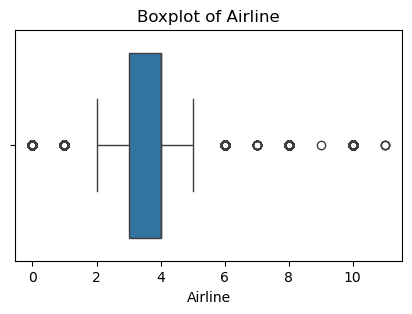

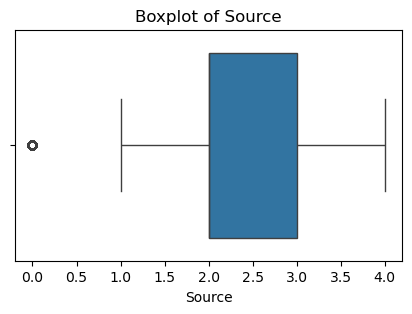

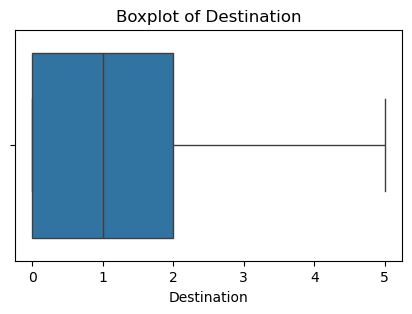

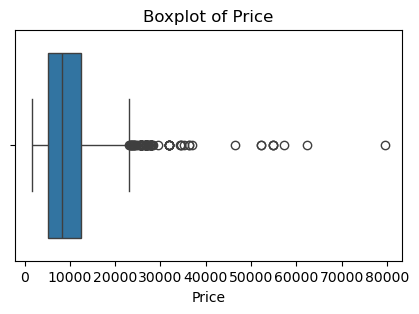

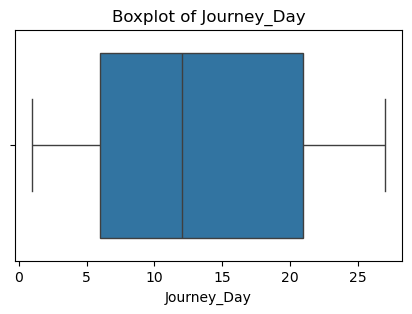

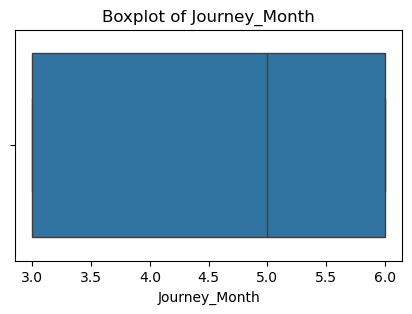

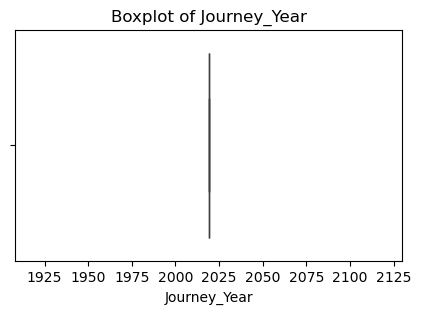

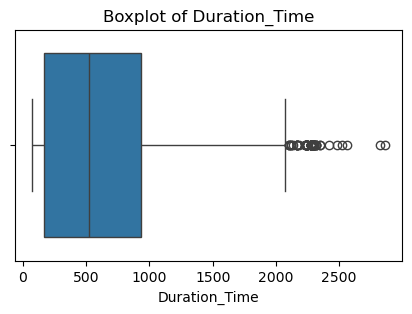

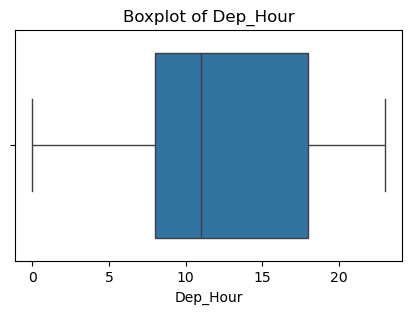

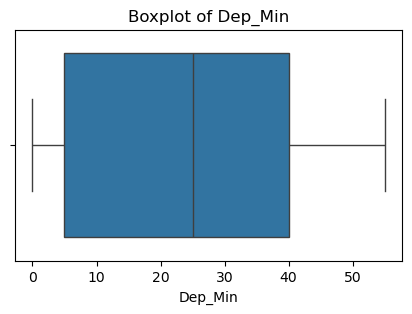

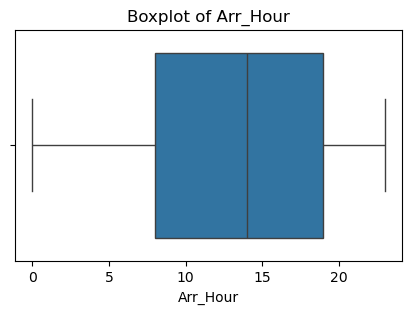

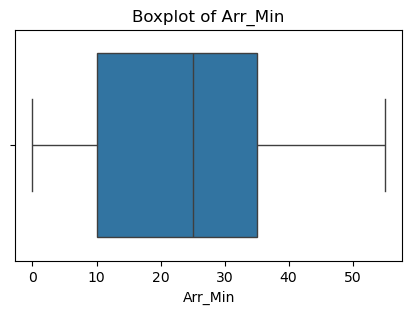

In [27]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [28]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_limit, upper_limit,np.where(df[col] < lower_limit, lower_limit, df[col]))

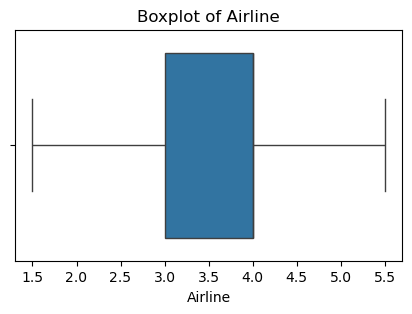

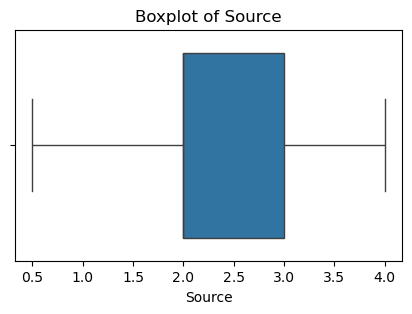

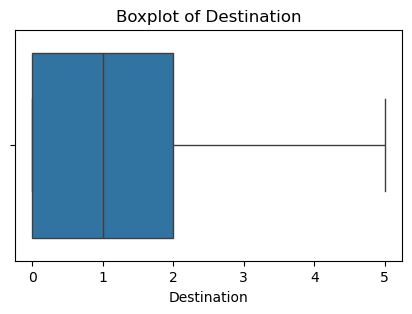

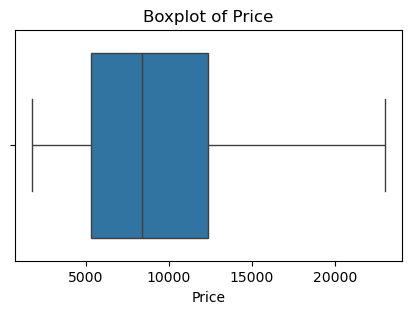

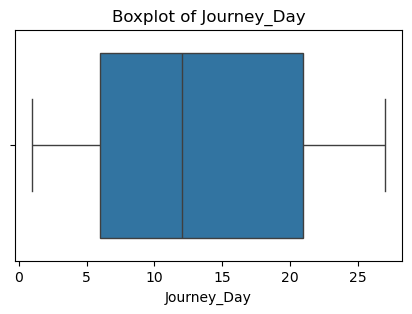

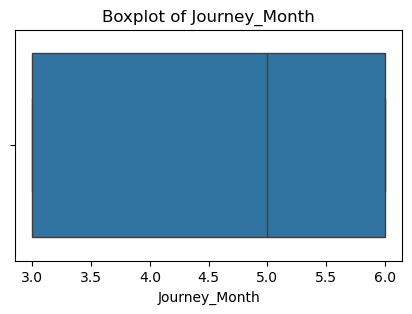

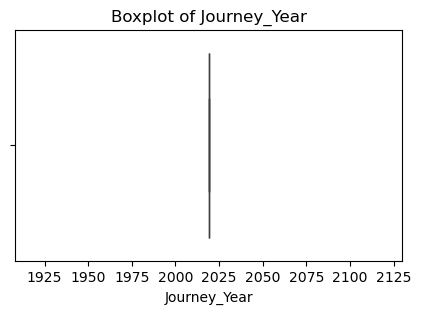

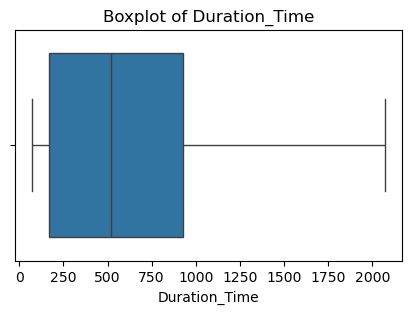

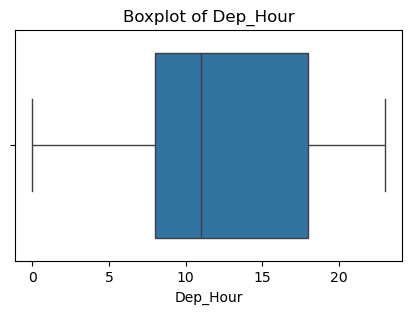

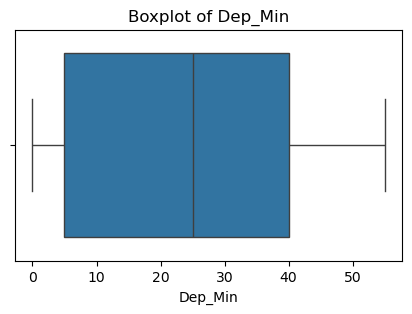

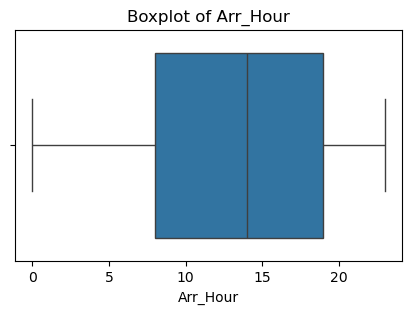

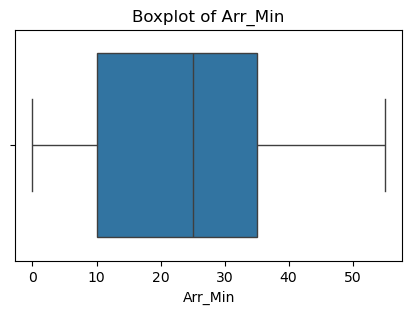

In [29]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [30]:
df.drop("Route",axis=1,inplace=True)

In [31]:
df.drop("Additional_Info",axis=1,inplace=True)

In [32]:
df.isna().sum()

Airline          0
Source           0
Destination      0
Total_Stops      0
Price            0
Journey_Day      0
Journey_Month    0
Journey_Year     0
Duration_Time    0
Dep_Hour         0
Dep_Min          0
Arr_Hour         0
Arr_Min          0
dtype: int64

In [33]:
df.head(2)

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Duration_Time,Dep_Hour,Dep_Min,Arr_Hour,Arr_Min
0,3.0,0.5,5.0,0,3897.0,24.0,3.0,2019.0,170.0,22.0,20.0,1.0,10.0
1,1.5,3.0,0.0,2,7662.0,1.0,5.0,2019.0,445.0,5.0,50.0,13.0,15.0


In [34]:
x=df.drop("Price",axis=1)
y=df["Price"]

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [38]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [39]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae,rmse,r2

In [41]:
results = {"Linear Regression": evaluate(y_test,lr_pred),"Random Forest": evaluate(y_test,rf_pred)}
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2 Score"]).T
results_df

,MAE,RMSE,R2 Score
Linear Regression,2313.980822,3049.248715,0.501572
Random Forest,1162.905389,1810.959386,0.824194


### Observation

Random Forest achieved the highest predictive accuracy.

### Conclusion

Ensemble learning models capture nonlinear pricing patterns more effectively than traditional regression models.

### Business Impact

Accurate fare prediction improves pricing decisions and customer satisfaction.

In [42]:
print(df["Total_Stops"].dtype)

object


In [43]:
print(df["Total_Stops"].unique())

[0 2 1 3 4]


In [44]:
print(df["Total_Stops"].dtype)

object


In [45]:
df["Total_Stops"] = df["Total_Stops"].astype(int)

In [46]:
print(df["Total_Stops"].dtype)

int64


In [47]:
x = df.drop("Price", axis=1)   
y = df["Price"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [48]:
print(x_train.select_dtypes(include='object').columns)

Index([], dtype='str')


In [49]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=6,
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

In [50]:
xgb_pred = xgb.predict(x_test)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1202.5267970897798
MSE : 2931288.099961318
RMSE : 1712.10049353457
R2 Score : 0.8428642877178045


In [52]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_pred
})

print(results.head(10))

       Actual     Predicted
6075  16655.0  17290.189453
3544   4959.0   6456.443359
9291   9187.0   9155.423828
5032   3858.0   4199.738281
2483  12898.0  13333.687500
9894  10529.0  10159.331055
346   16079.0  13371.721680
6365   7229.0   5963.851074
7624  10844.0  12876.394531
3393  16289.0  13560.412109


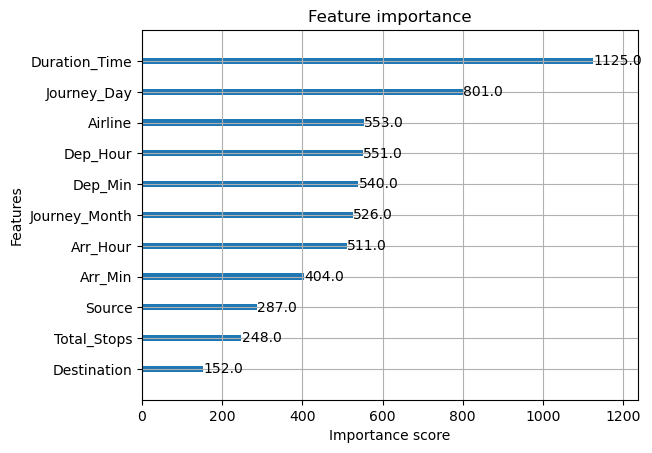

In [53]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb)
plt.show()

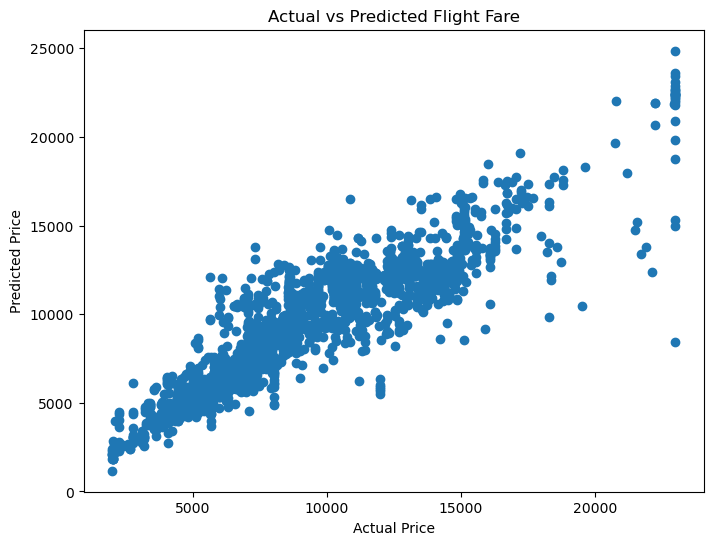

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Fare")
plt.show()

In [55]:
import pickle

pickle.dump(xgb, open("flight_fare_model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully


In [56]:
pickle.dump(le_airline, open("airline_encoder.pkl","wb"))
pickle.dump(le_source, open("source_encoder.pkl","wb"))
pickle.dump(le_destination, open("destination_encoder.pkl","wb"))

# Conclusion

The Flight Fare Prediction project successfully developed a machine learning model capable of estimating airline ticket prices based on travel characteristics.

### Key Findings

- Flight duration strongly influences fare.
- Non-stop flights are generally more expensive.
- Airline choice significantly impacts ticket pricing.
- Seasonal demand affects airfare trends.

### Best Model

XGBoost Regressor

### Business Value

This solution can support:

- Airline Revenue Management
- Dynamic Pricing Systems
- Travel Agencies
- Online Booking Platforms

in making data-driven pricing decisions.